# Lab Activity 02

## Effect of Image Filtering on Skin-Lesion Classification

### Objective

The objective of this experiment is to investigate how different spatial-domain image-processing filters affect the performance of pretrained deep-learning models for skin-lesion classification.

The experiments compare the classification performance of pretrained models using original images and images processed with average, Gaussian, median, sharpening, and Sobel filters.

The same dataset split, preprocessing procedure, training settings, and evaluation metrics will be maintained across the experiments to ensure a fair comparison.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFilter, ImageEnhance

dataset_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration"

train_path = os.path.join(dataset_path, "Train")
test_path = os.path.join(dataset_path, "Test")

selected_classes = [
    "melanoma",
    "basal cell carcinoma",
    "nevus",
    "pigmented benign keratosis"
]

print("Dataset path:", dataset_path)
print("Selected classes:", selected_classes)

Dataset path: /content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration
Selected classes: ['melanoma', 'basal cell carcinoma', 'nevus', 'pigmented benign keratosis']


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFilter, ImageEnhance

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [ ]:
dataset_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration"

train_path = os.path.join(dataset_path, "Train")
test_path = os.path.join(dataset_path, "Test")

selected_classes = [
    "melanoma",
    "basal cell carcinoma",
    "nevus",
    "pigmented benign keratosis"
]

class_names = selected_classes
num_classes = len(class_names)

print("Selected classes:")
for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

print("\nNumber of classes:", num_classes)

Selected classes:
0 : melanoma
1 : basal cell carcinoma
2 : nevus
3 : pigmented benign keratosis

Number of classes: 4


In [ ]:
import os

base_path = "/content/skin_cancer_dataset"

print("Does dataset folder exist?", os.path.exists(base_path))

if os.path.exists(base_path):
    print("\nContents of dataset folder:")
    print(os.listdir(base_path))

Does dataset folder exist? False


In [ ]:
!pip -q install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.3 MB/s eta 0:00:00


In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_56a1a63faccceec2d4b171e63e411970"

In [ ]:
!kaggle datasets list -s skin-cancer9-classesisic

ref                                   title                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------  ----------------  ----------  --------------------------  -------------  ---------  ---------------  
nodoubttome/skin-cancer9-classesisic  Skin Cancer ISIC  1647873564  2019-08-26 18:59:21.257000          36305        318  0.75             


In [ ]:
!kaggle datasets download -d nodoubttome/skin-cancer9-classesisic

Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
License(s): other
100% 786M/786M [00:06<00:00, 119MB/s]



In [ ]:
!mkdir -p /content/skin_cancer_dataset
!unzip -q skin-cancer9-classesisic.zip -d /content/skin_cancer_dataset

In [ ]:
import os

base_path = "/content/skin_cancer_dataset"

for root, dirs, files in os.walk(base_path):
    if files:
        print(root, "->", len(files), "images")

/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/seborrheic keratosis -> 77 images
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma -> 376 images
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/nevus -> 357 images
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma -> 181 images
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/melanoma -> 438 images
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/pigmented benign keratosis -> 462 images
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/vascular lesion -> 139 images
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/der

In [ ]:
image_records = []

# Collect images from the Train folders
for class_name in selected_classes:
    class_folder = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_records.append({
                "filepath": os.path.join(class_folder, file_name),
                "filename": file_name,
                "class": class_name
            })

# Collect images from the Test folders
for class_name in selected_classes:
    class_folder = os.path.join(test_path, class_name)

    for file_name in os.listdir(class_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_records.append({
                "filepath": os.path.join(class_folder, file_name),
                "filename": file_name,
                "class": class_name
            })

df = pd.DataFrame(image_records)

print("Total images:", len(df))
print("\nImages per class:")
print(df["class"].value_counts())

Total images: 1697

Images per class:
class
pigmented benign keratosis    478
melanoma                      454
basal cell carcinoma          392
nevus                         373
Name: count, dtype: int64


In [ ]:
train_records = []
test_records = []

for class_name in selected_classes:

    # Training images
    class_train_folder = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_train_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            train_records.append({
                "filepath": os.path.join(class_train_folder, file_name),
                "filename": file_name,
                "class": class_name
            })

    # Test images
    class_test_folder = os.path.join(test_path, class_name)

    for file_name in os.listdir(class_test_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            test_records.append({
                "filepath": os.path.join(class_test_folder, file_name),
                "filename": file_name,
                "class": class_name
            })

train_df = pd.DataFrame(train_records)
test_df = pd.DataFrame(test_records)

# Stratified train-validation split
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["class"],
    random_state=SEED
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 1306
Validation images: 327
Test images: 64


In [ ]:
print("Training distribution:")
print(train_df["class"].value_counts())

print("\nValidation distribution:")
print(val_df["class"].value_counts())

print("\nTest distribution:")
print(test_df["class"].value_counts())

Training distribution:
class
pigmented benign keratosis    369
melanoma                      350
basal cell carcinoma          301
nevus                         286
Name: count, dtype: int64

Validation distribution:
class
pigmented benign keratosis    93
melanoma                      88
basal cell carcinoma          75
nevus                         71
Name: count, dtype: int64

Test distribution:
class
melanoma                      16
basal cell carcinoma          16
nevus                         16
pigmented benign keratosis    16
Name: count, dtype: int64


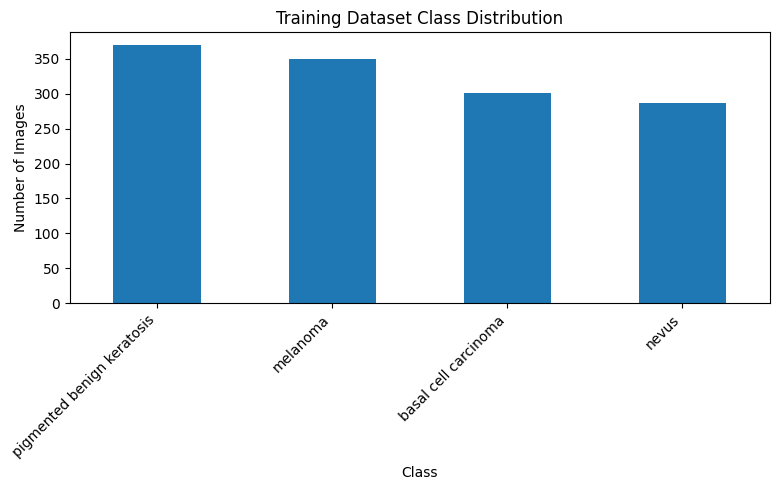

In [ ]:
import matplotlib.pyplot as plt

# Count images in each class
train_counts = train_df["class"].value_counts()

# Plot class distribution
plt.figure(figsize=(8, 5))
train_counts.plot(kind="bar")

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
print(train_df.columns)

Index(['filepath', 'filename', 'class'], dtype='object')


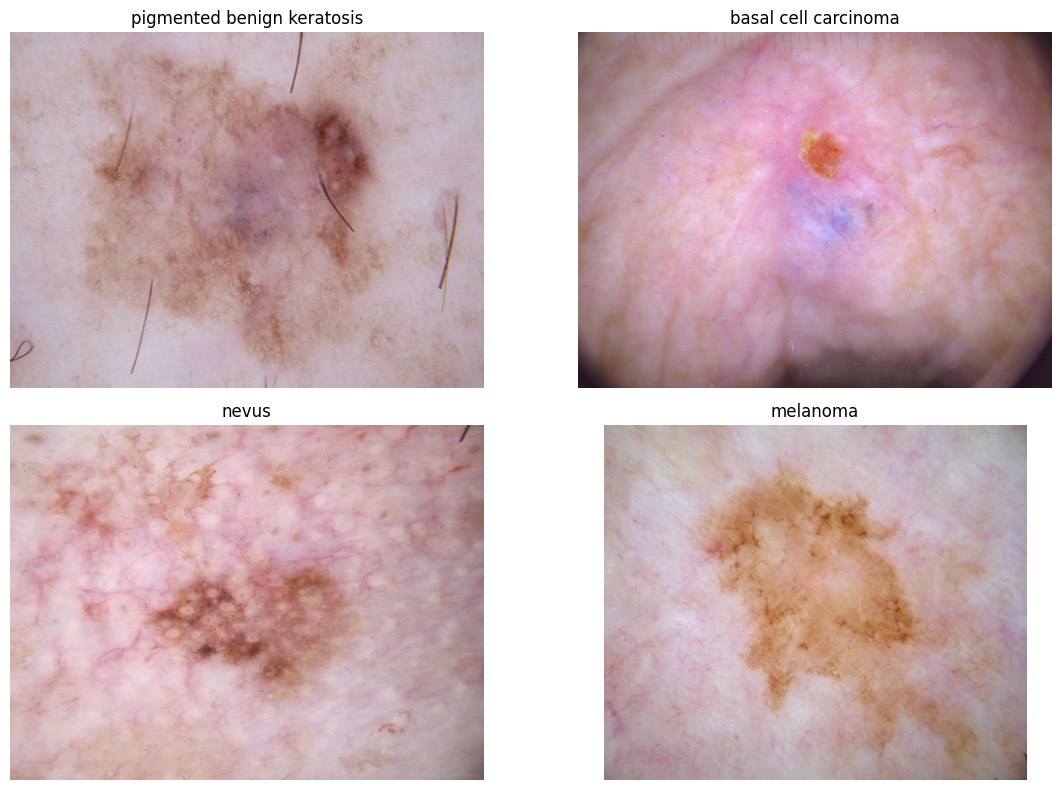

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Get one sample image from each class
sample_classes = train_df["class"].unique()

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(sample_classes):
    # Select one image from the current class
    sample = train_df[train_df["class"] == class_name].iloc[0]

    # Load the image using the filepath column
    image = Image.open(sample["filepath"])

    # Display image
    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
from collections import Counter

# Store image dimensions
image_sizes = []

for filepath in train_df["filepath"]:
    with Image.open(filepath) as img:
        image_sizes.append(img.size)

# Count the most common image sizes
size_counts = Counter(image_sizes)

print("Total images checked:", len(image_sizes))
print("\nMost common image dimensions:")

for size, count in size_counts.most_common(10):
    print(f"{size}: {count} images")

Total images checked: 1306

Most common image dimensions:
(600, 450): 735 images
(1024, 768): 249 images
(3072, 2304): 65 images
(767, 576): 65 images
(919, 802): 48 images
(1504, 1129): 26 images
(2048, 1536): 23 images
(824, 719): 14 images
(3872, 2592): 8 images
(962, 674): 6 images


In [ ]:
from PIL import Image
from collections import Counter

# Check the color mode of each training image
image_modes = []

for filepath in train_df["filepath"]:
    with Image.open(filepath) as img:
        image_modes.append(img.mode)

# Count each image mode
mode_counts = Counter(image_modes)

print("Image color modes:")
for mode, count in mode_counts.items():
    print(f"{mode}: {count} images")

Image color modes:
RGB: 1306 images


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [ ]:
# Image and training settings

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Image size: (224, 224)
Batch size: 32
Epochs: 10
Learning rate: 0.001


In [ ]:
# Get the four class names
class_names = sorted(train_df["class"].unique())

# Create a mapping from class name to numerical label
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}

print("Class names:")
print(class_names)

print("\nClass mapping:")
print(class_to_index)

Class names:
['basal cell carcinoma', 'melanoma', 'nevus', 'pigmented benign keratosis']

Class mapping:
{'basal cell carcinoma': 0, 'melanoma': 1, 'nevus': 2, 'pigmented benign keratosis': 3}


In [ ]:
# Create numerical labels for each dataset split

train_df["label"] = train_df["class"].map(class_to_index)
val_df["label"] = val_df["class"].map(class_to_index)
test_df["label"] = test_df["class"].map(class_to_index)

# Check the result
print("Training labels:")
print(train_df[["class", "label"]].head())

print("\nValidation labels:")
print(val_df[["class", "label"]].head())

print("\nTest labels:")
print(test_df[["class", "label"]].head())

Training labels:
                        class  label
0  pigmented benign keratosis      3
1        basal cell carcinoma      0
2                       nevus      2
3  pigmented benign keratosis      3
4  pigmented benign keratosis      3

Validation labels:
                        class  label
0        basal cell carcinoma      0
1                       nevus      2
2                    melanoma      1
3        basal cell carcinoma      0
4  pigmented benign keratosis      3

Test labels:
      class  label
0  melanoma      1
1  melanoma      1
2  melanoma      1
3  melanoma      1
4  melanoma      1


In [ ]:
import tensorflow as tf

def create_dataset(dataframe, shuffle=False):
    """
    Create a TensorFlow dataset from image file paths and labels.
    """

    filepaths = dataframe["filepath"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    # Load and preprocess images
    def load_image(filepath, label):
        image = tf.io.read_file(filepath)
        image = tf.image.decode_image(
            image,
            channels=3,
            expand_animations=False
        )

        # Resize all images to 224 × 224
        image = tf.image.resize(image, IMG_SIZE)

        # Convert pixel values from 0–255 to 0–1
        image = tf.cast(image, tf.float32) / 255.0

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Create TensorFlow datasets

train_dataset = create_dataset(train_df, shuffle=True)
val_dataset = create_dataset(val_df, shuffle=False)
test_dataset = create_dataset(test_df, shuffle=False)

print("Train dataset created")
print("Validation dataset created")
print("Test dataset created")

Train dataset created
Validation dataset created
Test dataset created


In [ ]:
# Check one batch from the training dataset

images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image pixel range:", images.numpy().min(), "to", images.numpy().max())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image pixel range: 0.0 to 1.0


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, DenseNet121

print("TensorFlow version:", tf.__version__)
print("Model libraries loaded successfully.")

TensorFlow version: 2.20.0
Model libraries loaded successfully.


In [ ]:
print("GPU devices:")
print(tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("\nGPU is available. Training can use the GPU.")
else:
    print("\nNo GPU detected. Training will run on CPU.")

GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

GPU is available. Training can use the GPU.


In [ ]:
import numpy as np
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [ ]:
vgg16_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
for layer in vgg16_model.layers:
    layer.trainable = False

# Add our classification layers
vgg16_model = models.Sequential([
    vgg16_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
densenet_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
for layer in densenet_model.layers:
    layer.trainable = False

# Add classification layers
densenet_model = models.Sequential([
    densenet_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,220 (27.35 MB)

 Trainable params: 131,716 (514.52 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
import torch

print("PyTorch version:", torch.__version__)

try:
    import torchvision
    print("Torchvision version:", torchvision.__version__)
    print("Torchvision is available.")
except Exception as e:
    print("Torchvision is not available.")
    print("Error:", e)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Torchvision is available.


In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
resnet18_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# Replace the final classification layer for 4 classes
num_features = resnet18_model.fc.in_features
resnet18_model.fc = torch.nn.Linear(num_features, 4)

print("ResNet18 loaded successfully.")
print("Output classes:", 4)
print("Final layer:", resnet18_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 64.4MB/s]


ResNet18 loaded successfully.
Output classes: 4
Final layer: Linear(in_features=512, out_features=4, bias=True)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Freeze all pretrained layers
for param in resnet18_model.parameters():
    param.requires_grad = False

# Keep only the new final layer trainable
for param in resnet18_model.fc.parameters():
    param.requires_grad = True

resnet18_model = resnet18_model.to(device)

print("Device:", device)
print("ResNet18 moved to device successfully.")
print("Trainable final layer:", resnet18_model.fc)

Device: cuda
ResNet18 moved to device successfully.
Trainable final layer: Linear(in_features=512, out_features=4, bias=True)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("Filtering libraries loaded successfully.")

OpenCV version: 5.0.0
Filtering libraries loaded successfully.


In [ ]:
def apply_filter(image, filter_name):
    """
    Apply one of the required image filters.

    Parameters:
        image: RGB image as a NumPy array
        filter_name: Name of the filter

    Returns:
        Filtered RGB image
    """

    if filter_name == "original":
        return image

    elif filter_name == "mean":
        return cv2.blur(image, (5, 5))

    elif filter_name == "gaussian":
        return cv2.GaussianBlur(image, (5, 5), 0)

    elif filter_name == "median":
        return cv2.medianBlur(image, 5)

    elif filter_name == "sharpen":
        kernel = np.array([
            [0, -1,  0],
            [-1, 5, -1],
            [0, -1,  0]
        ])
        return cv2.filter2D(image, -1, kernel)

    elif filter_name == "sobel":
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        sobel_x = cv2.Sobel(
            gray, cv2.CV_64F, 1, 0, ksize=3
        )
        sobel_y = cv2.Sobel(
            gray, cv2.CV_64F, 0, 1, ksize=3
        )

        sobel = cv2.magnitude(sobel_x, sobel_y)
        sobel = cv2.normalize(
            sobel, None, 0, 255, cv2.NORM_MINMAX
        )

        sobel = sobel.astype(np.uint8)

        # Convert back to 3 channels for CNN input
        return cv2.cvtColor(sobel, cv2.COLOR_GRAY2RGB)

    else:
        raise ValueError(f"Unknown filter: {filter_name}")


FILTERS = [
    "original",
    "mean",
    "gaussian",
    "median",
    "sharpen",
    "sobel"
]

print("Available filters:")
for filter_name in FILTERS:
    print("-", filter_name)

Available filters:
- original
- mean
- gaussian
- median
- sharpen
- sobel


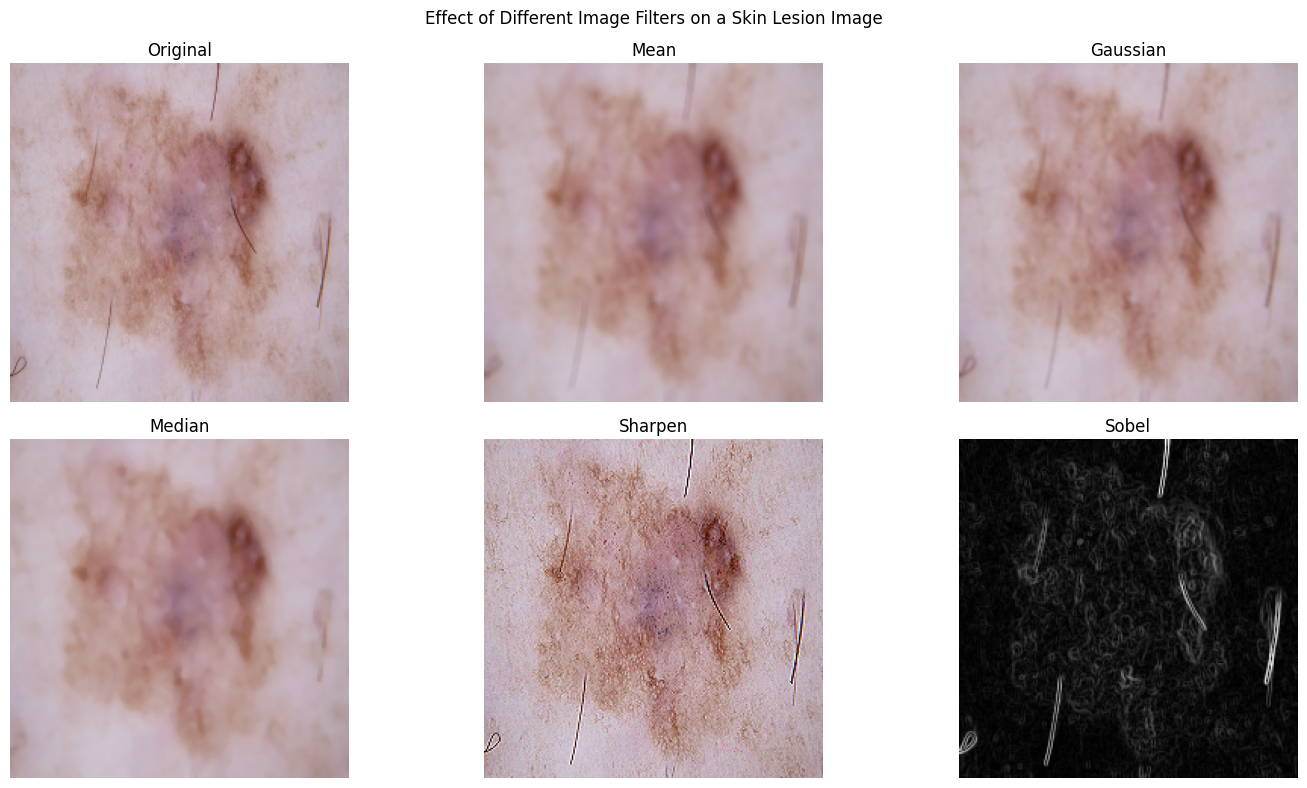

In [ ]:
# Select one sample image
sample_path = train_df.iloc[0]["filepath"]

# Load image
sample_image = cv2.imread(sample_path)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

# Resize for consistent display
sample_image = cv2.resize(sample_image, IMG_SIZE)

# Display original + all filters
plt.figure(figsize=(15, 8))

for i, filter_name in enumerate(FILTERS):
    filtered_image = apply_filter(sample_image, filter_name)

    plt.subplot(2, 3, i + 1)
    plt.imshow(filtered_image)
    plt.title(filter_name.capitalize())
    plt.axis("off")

plt.suptitle("Effect of Different Image Filters on a Skin Lesion Image")
plt.tight_layout()
plt.show()

In [ ]:
def load_and_filter_image_tf(filepath, filter_name):
    """
    Load an image, resize it to 224x224,
    apply the selected filter, and normalize to 0-1.
    """

    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # Convert TensorFlow image to NumPy for OpenCV filtering
    def apply_cv_filter(image_np):
        image_np = np.clip(image_np, 0, 255).astype(np.uint8)
        filtered = apply_filter(image_np, filter_name)
        return filtered.astype(np.float32)

    image = tf.numpy_function(
        apply_cv_filter,
        [image],
        tf.float32
    )

    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))

    # Normalize pixel values
    image = image / 255.0

    return image


def create_filtered_tf_dataset(dataframe, filter_name, shuffle=False):
    """
    Create a TensorFlow dataset using a selected filter.
    """

    filepaths = dataframe["filepath"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    def load_image(filepath, label):
        image = load_and_filter_image_tf(
            filepath,
            filter_name
        )
        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


print("Filtered TensorFlow dataset functions created successfully.")

Filtered TensorFlow dataset functions created successfully.


In [ ]:
gaussian_test_dataset = create_filtered_tf_dataset(
    train_df,
    "gaussian",
    shuffle=False
)

images, labels = next(iter(gaussian_test_dataset))

print("Filtered image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", images.numpy().min(), "to", images.numpy().max())

Filtered image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 1.0


In [ ]:
def create_vgg16_model():
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def create_densenet121_model():
    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Fresh model creation functions are ready.")

Fresh model creation functions are ready.


In [ ]:
def train_tf_model(model, train_dataset, val_dataset):
    """
    Train a TensorFlow model using the fixed experiment settings.
    """

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        verbose=1
    )

    return history


print("TensorFlow training function created successfully.")

TensorFlow training function created successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_tf_model(model, test_dataset):
    """
    Evaluate a TensorFlow model on the test dataset.
    """

    y_true = []
    y_prob = []

    for images, labels in test_dataset:
        probabilities = model.predict(images, verbose=0)

        y_true.extend(labels.numpy())
        y_prob.extend(probabilities)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    try:
        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        auc = np.nan

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "auc": auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm
    }


print("TensorFlow evaluation function created successfully.")

TensorFlow evaluation function created successfully.


In [ ]:
vgg16_train_baseline = create_filtered_tf_dataset(
    train_df,
    "original",
    shuffle=True
)

vgg16_val_baseline = create_filtered_tf_dataset(
    val_df,
    "original",
    shuffle=False
)

vgg16_test_baseline = create_filtered_tf_dataset(
    test_df,
    "original",
    shuffle=False
)

print("VGG16 baseline datasets created.")
print("Filter: Original")
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

VGG16 baseline datasets created.
Filter: Original
Train images: 1306
Validation images: 327
Test images: 64


In [ ]:
# Create a fresh VGG16 model
vgg16_baseline_model = create_vgg16_model()

# Train on original (unfiltered) images
vgg16_baseline_history = train_tf_model(
    vgg16_baseline_model,
    vgg16_train_baseline,
    vgg16_val_baseline
)

print("VGG16 baseline training completed.")

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 52s 665ms/step - accuracy: 0.2718 - loss: 1.4212 - val_accuracy: 0.3945 - val_loss: 1.3300
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 251ms/step - accuracy: 0.3660 - loss: 1.3359 - val_accuracy: 0.3670 - val_loss: 1.2974
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 255ms/step - accuracy: 0.3874 - loss: 1.2971 - val_accuracy: 0.4526 - val_loss: 1.2594
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.4349 - loss: 1.2539 - val_accuracy: 0.4893 - val_loss: 1.2339
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.4541 - loss: 1.2321 - val_accuracy: 0.4954 - val_loss: 1.2029
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.4556 - loss: 1.2174 - val_accuracy: 0.5107 - val_loss: 1.1868
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.4877 - loss: 1.1786 - val_accuracy: 0.5382 - val_loss: 1.1636
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.5061 - loss: 1.1651 - val_accu

In [ ]:
import gc
import pandas as pd
import tensorflow as tf

# Store all results here
experiment_results = []

models_to_run = {
    "VGG16": create_vgg16_model,
    "DenseNet121": create_densenet121_model
}

for model_name, model_creator in models_to_run.items():

    print("\n" + "="*60)
    print(f"STARTING MODEL: {model_name}")
    print("="*60)

    for filter_name in FILTERS:

        print(f"\n>>> {model_name} + {filter_name}")

        # Create datasets
        train_data = create_filtered_tf_dataset(
            train_df,
            filter_name,
            shuffle=True
        )

        val_data = create_filtered_tf_dataset(
            val_df,
            filter_name,
            shuffle=False
        )

        test_data = create_filtered_tf_dataset(
            test_df,
            filter_name,
            shuffle=False
        )

        # Fresh model for every experiment
        model = model_creator()

        # Train
        history = model.fit(
            train_data,
            validation_data=val_data,
            epochs=EPOCHS,
            verbose=0
        )

        # Evaluate
        metrics = evaluate_tf_model(
            model,
            test_data
        )

        # Save only required table values
        experiment_results.append({
            "Model": model_name,
            "Filter": filter_name,
            "Accuracy": metrics["accuracy"],
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1"],
            "Macro-F1": metrics["macro_f1"],
            "Balanced Accuracy": metrics["balanced_accuracy"],
            "AUC": metrics["auc"]
        })

        print(
            f"Accuracy: {metrics['accuracy']:.4f} | "
            f"Macro-F1: {metrics['macro_f1']:.4f} | "
            f"AUC: {metrics['auc']:.4f}"
        )

        # Clear memory
        del model
        del train_data, val_data, test_data
        gc.collect()
        tf.keras.backend.clear_session()

# Create final table
results_df = pd.DataFrame(experiment_results)

print("\n" + "="*80)
print("FINAL RESULTS TABLE")
print("="*80)

display(
    results_df.round(4)
)


STARTING MODEL: VGG16

>>> VGG16 + original
Accuracy: 0.4844 | Macro-F1: 0.4902 | AUC: 0.7389

>>> VGG16 + mean
Accuracy: 0.5938 | Macro-F1: 0.5856 | AUC: 0.7598

>>> VGG16 + gaussian
Accuracy: 0.5625 | Macro-F1: 0.5519 | AUC: 0.7660

>>> VGG16 + median
Accuracy: 0.5156 | Macro-F1: 0.4898 | AUC: 0.7100

>>> VGG16 + sharpen


Accuracy: 0.4375 | Macro-F1: 0.4402 | AUC: 0.7217

>>> VGG16 + sobel


Accuracy: 0.2656 | Macro-F1: 0.2641 | AUC: 0.5446

STARTING MODEL: DenseNet121

>>> DenseNet121 + original
Accuracy: 0.5781 | Macro-F1: 0.5655 | AUC: 0.8672

>>> DenseNet121 + mean
Accuracy: 0.6406 | Macro-F1: 0.6258 | AUC: 0.8535

>>> DenseNet121 + gaussian
Accuracy: 0.6406 | Macro-F1: 0.6174 | AUC: 0.8532

>>> DenseNet121 + median
Accuracy: 0.6094 | Macro-F1: 0.6004 | AUC: 0.8262

>>> DenseNet121 + sharpen
Accuracy: 0.5469 | Macro-F1: 0.5158 | AUC: 0.8242

>>> DenseNet121 + sobel
Accuracy: 0.4219 | Macro-F1: 0.4149 | AUC: 0.6800

FINAL RESULTS TABLE


,Model,Filter,Accuracy,Precision,Recall,F1,Macro-F1,Balanced Accuracy,AUC
0,VGG16,original,0.4844,0.5358,0.4844,0.4902,0.4902,0.4844,0.7389
1,VGG16,mean,0.5938,0.6125,0.5938,0.5856,0.5856,0.5938,0.7598
2,VGG16,gaussian,0.5625,0.5833,0.5625,0.5519,0.5519,0.5625,0.7660
3,VGG16,median,0.5156,0.5248,0.5156,0.4898,0.4898,0.5156,0.7100
4,VGG16,sharpen,0.4375,0.4729,0.4375,0.4402,0.4402,0.4375,0.7217
5,VGG16,sobel,0.2656,0.2750,0.2656,0.2641,0.2641,0.2656,0.5446
6,DenseNet121,original,0.5781,0.5704,0.5781,0.5655,0.5655,0.5781,0.8672
7,DenseNet121,mean,0.6406,0.6625,0.6406,0.6258,0.6258,0.6406,0.8535
8,DenseNet121,gaussian,0.6406,0.6562,0.6406,0.6174,0.6174,0.6406,0.8532
9,DenseNet121,median,0.6094,0.6178,0.6094,0.6004,0.6004,0.6094,0.8262


In [ ]:
# ============================================================
# RESNET18 - ALL 6 FILTER EXPERIMENTS
# ============================================================

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)
from PIL import Image
import gc

class ResNetDataset(Dataset):
    def __init__(self, dataframe, filter_name):
        self.dataframe = dataframe.reset_index(drop=True)
        self.filter_name = filter_name

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["filepath"]).convert("RGB")
        image = np.array(image)
        image = cv2.resize(image, IMG_SIZE)

        image = apply_filter(image, self.filter_name)

        # Convert to tensor: HWC -> CHW and normalize 0-1
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        label = int(row["label"])

        return image, label


def create_resnet_loader(dataframe, filter_name, shuffle=False):
    dataset = ResNetDataset(dataframe, filter_name)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True
    )


def evaluate_resnet18(model, loader):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            outputs = model(images)

            probabilities = torch.softmax(
                outputs, dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())
            y_prob.extend(probabilities.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, y_pred
        ),
        "auc": roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    }


resnet_results = []

for filter_name in FILTERS:

    print(f"\n>>> ResNet18 + {filter_name}")

    # Fresh ResNet18
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    model.fc = torch.nn.Linear(
        model.fc.in_features,
        4
    )

    # Freeze pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device)

    # Data
    train_loader = create_resnet_loader(
        train_df, filter_name, shuffle=True
    )

    val_loader = create_resnet_loader(
        val_df, filter_name, shuffle=False
    )

    test_loader = create_resnet_loader(
        test_df, filter_name, shuffle=False
    )

    # Optimizer
    optimizer = torch.optim.Adam(
        model.fc.parameters(),
        lr=LEARNING_RATE
    )

    criterion = torch.nn.CrossEntropyLoss()

    # Training
    for epoch in range(EPOCHS):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

    # Evaluation
    metrics = evaluate_resnet18(
        model,
        test_loader
    )

    resnet_results.append({
        "Model": "ResNet18",
        "Filter": filter_name,
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "Macro-F1": metrics["macro_f1"],
        "Balanced Accuracy": metrics["balanced_accuracy"],
        "AUC": metrics["auc"]
    })

    print(
        f"Accuracy: {metrics['accuracy']:.4f} | "
        f"Macro-F1: {metrics['macro_f1']:.4f} | "
        f"AUC: {metrics['auc']:.4f}"
    )

    del model
    torch.cuda.empty_cache()
    gc.collect()


# Add ResNet18 results to our existing table
resnet_df = pd.DataFrame(resnet_results)

results_df = pd.concat(
    [results_df, resnet_df],
    ignore_index=True
)

print("\n" + "="*80)
print("COMPLETE LAB 02 RESULTS — 18 EXPERIMENTS")
print("="*80)

display(results_df.round(4))


>>> ResNet18 + original
Accuracy: 0.5625 | Macro-F1: 0.5441 | AUC: 0.8223

>>> ResNet18 + mean
Accuracy: 0.5938 | Macro-F1: 0.5757 | AUC: 0.8558

>>> ResNet18 + gaussian
Accuracy: 0.6094 | Macro-F1: 0.5876 | AUC: 0.8643

>>> ResNet18 + median
Accuracy: 0.5781 | Macro-F1: 0.5398 | AUC: 0.8053

>>> ResNet18 + sharpen
Accuracy: 0.6875 | Macro-F1: 0.6521 | AUC: 0.8652

>>> ResNet18 + sobel
Accuracy: 0.5000 | Macro-F1: 0.4861 | AUC: 0.7744

COMPLETE LAB 02 RESULTS — 18 EXPERIMENTS


,Model,Filter,Accuracy,Precision,Recall,F1,Macro-F1,Balanced Accuracy,AUC
0,VGG16,original,0.4844,0.5358,0.4844,0.4902,0.4902,0.4844,0.7389
1,VGG16,mean,0.5938,0.6125,0.5938,0.5856,0.5856,0.5938,0.7598
2,VGG16,gaussian,0.5625,0.5833,0.5625,0.5519,0.5519,0.5625,0.7660
3,VGG16,median,0.5156,0.5248,0.5156,0.4898,0.4898,0.5156,0.7100
4,VGG16,sharpen,0.4375,0.4729,0.4375,0.4402,0.4402,0.4375,0.7217
5,VGG16,sobel,0.2656,0.2750,0.2656,0.2641,0.2641,0.2656,0.5446
6,DenseNet121,original,0.5781,0.5704,0.5781,0.5655,0.5655,0.5781,0.8672
7,DenseNet121,mean,0.6406,0.6625,0.6406,0.6258,0.6258,0.6406,0.8535
8,DenseNet121,gaussian,0.6406,0.6562,0.6406,0.6174,0.6174,0.6406,0.8532
9,DenseNet121,median,0.6094,0.6178,0.6094,0.6004,0.6004,0.6094,0.8262


In [ ]:
# Final comparison table for Lab 02

final_table = results_df.copy()

# Round values for clean reporting
for col in ["Accuracy", "Precision", "Recall", "F1", "Macro-F1",
            "Balanced Accuracy", "AUC"]:
    final_table[col] = (final_table[col] * 100).round(2)

final_table

,Model,Filter,Accuracy,Precision,Recall,F1,Macro-F1,Balanced Accuracy,AUC
0,VGG16,original,48.44,53.58,48.44,49.02,49.02,48.44,73.89
1,VGG16,mean,59.38,61.25,59.38,58.56,58.56,59.38,75.98
2,VGG16,gaussian,56.25,58.33,56.25,55.19,55.19,56.25,76.60
3,VGG16,median,51.56,52.48,51.56,48.98,48.98,51.56,71.00
4,VGG16,sharpen,43.75,47.29,43.75,44.02,44.02,43.75,72.17
5,VGG16,sobel,26.56,27.50,26.56,26.41,26.41,26.56,54.46
6,DenseNet121,original,57.81,57.04,57.81,56.55,56.55,57.81,86.72
7,DenseNet121,mean,64.06,66.25,64.06,62.58,62.58,64.06,85.35
8,DenseNet121,gaussian,64.06,65.62,64.06,61.74,61.74,64.06,85.32
9,DenseNet121,median,60.94,61.78,60.94,60.04,60.04,60.94,82.62


In [ ]:
# Find the best filter for each model based on Accuracy and Macro-F1

best_accuracy = final_table.loc[
    final_table.groupby("Model")["Accuracy"].idxmax(),
    ["Model", "Filter", "Accuracy", "Macro-F1", "Balanced Accuracy", "AUC"]
].reset_index(drop=True)

best_accuracy

,Model,Filter,Accuracy,Macro-F1,Balanced Accuracy,AUC
0,DenseNet121,mean,64.06,62.58,64.06,85.35
1,ResNet18,sharpen,68.75,65.21,68.75,86.52
2,VGG16,mean,59.38,58.56,59.38,75.98


In [ ]:
# Average performance of each filter across the 3 models

filter_comparison = final_table.groupby("Filter")[
    ["Accuracy", "Macro-F1", "Balanced Accuracy", "AUC"]
].mean().round(2).reset_index()

filter_comparison

,Filter,Accuracy,Macro-F1,Balanced Accuracy,AUC
0,gaussian,60.42,58.56,60.42,82.78
1,mean,60.94,59.57,60.94,82.30
2,median,56.77,54.33,56.77,78.05
3,original,54.17,53.33,54.17,80.95
4,sharpen,55.73,53.60,55.73,80.37
5,sobel,39.58,38.84,39.58,66.63


In [ ]:
# Change in performance compared with the original images

baseline = (
    final_table[final_table["Filter"] == "original"]
    .set_index("Model")
)

changes = final_table[final_table["Filter"] != "original"].copy()

for metric in ["Accuracy", "Macro-F1", "Balanced Accuracy", "AUC"]:
    changes[f"{metric} Change"] = (
        changes.apply(
            lambda row: row[metric] - baseline.loc[row["Model"], metric],
            axis=1
        )
    ).round(2)

baseline_change_table = changes[
    ["Model", "Filter", "Accuracy Change",
     "Macro-F1 Change", "Balanced Accuracy Change", "AUC Change"]
].reset_index(drop=True)

baseline_change_table

,Model,Filter,Accuracy Change,Macro-F1 Change,Balanced Accuracy Change,AUC Change
0,VGG16,mean,10.94,9.54,10.94,2.09
1,VGG16,gaussian,7.81,6.17,7.81,2.71
2,VGG16,median,3.12,-0.04,3.12,-2.89
3,VGG16,sharpen,-4.69,-5.00,-4.69,-1.72
4,VGG16,sobel,-21.88,-22.61,-21.88,-19.43
5,DenseNet121,mean,6.25,6.03,6.25,-1.37
6,DenseNet121,gaussian,6.25,5.19,6.25,-1.40
7,DenseNet121,median,3.13,3.49,3.13,-4.10
8,DenseNet121,sharpen,-3.12,-4.97,-3.12,-4.30
9,DenseNet121,sobel,-15.62,-15.06,-15.62,-18.72
